## Логистическая регрессия. Метод опорных векторов. Работа с текстами.

# Logistic Regression  и SVM 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

#### Сравнение методов



Сгенерируем синтетические данные.

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# фиксируем random_state для воспроизводимости результатов
X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=5, n_redundant=5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

__Случайный классификатор__

Для начала зададим самую простую модель, которая на каждом объекте выдаёт случайный ответ. По тестовой выборке вычислим AUC-ROC, AUC-PR.

In [4]:
from sklearn.dummy import DummyClassifier
random_classifier = DummyClassifier(strategy='uniform', random_state=42).fit(X_train, y_train)
y_random = random_classifier.predict_proba(X_test)[:, 1]
y_random

array([0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5], shape=(3000,))

*Ниже приведен **пример** работы* со встроенными функциями `sklearn` для отрисовки ROC и PR кривых, сохранения метрик. Пайплайн можно изменять как вам удобно.

In [5]:
from sklearn.metrics import auc
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay

from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

Random Classifier metrics
AUC-PR: 0.75283
AUC-ROC: 0.50000


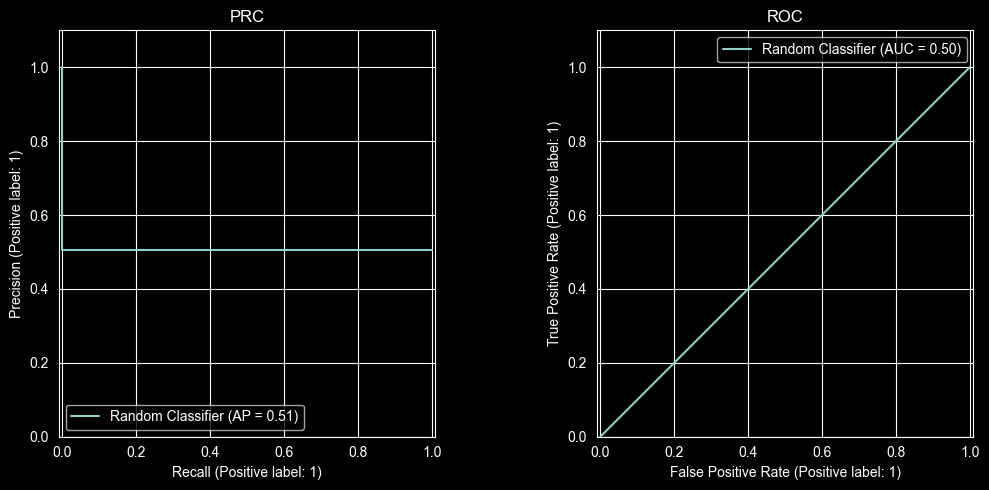

In [6]:
def depict_pr_roc(y_true, y_pred, classifier_name='Some Classifier', ax=None):
  if ax is None:
    fig, ax = plt.subplots(1, 2, figsize=(11, 5))

  print(classifier_name, 'metrics')
  PrecisionRecallDisplay.from_predictions(y_true, y_pred, ax=ax[0], name=classifier_name)
  precision, recall, _ = precision_recall_curve(y_true, y_pred)
  print('AUC-PR: %.5f' % auc(recall, precision))
  ax[0].set_title("PRC")
  ax[0].set_ylim(0, 1.1)

  RocCurveDisplay.from_predictions(y_true, y_pred, ax=ax[1], name=classifier_name)
  print('AUC-ROC: %.5f' % roc_auc_score(y_true, y_pred))
  ax[1].set_title("ROC")
  ax[1].set_ylim(0, 1.1)

  plt.tight_layout()
  plt.legend()


depict_pr_roc(y_test, y_random, 'Random Classifier')

In [7]:
# dataframe для сравнения
# методов классификации по метрикам
df_metrics = pd.DataFrame(columns=['AUC_PR', 'AUC_ROC', 'reg_const'])
precision, recall, _ = precision_recall_curve(y_test, y_random)
# добавление очередной строки с характеристиками метода
df_metrics.loc['Random Classifier'] = [
      auc(recall, precision),
      roc_auc_score(y_test, y_random),
      0
]

# по аналогии результаты следующих экспериментов можно будет собрать в табличку
df_metrics

,AUC_PR,AUC_ROC,reg_const
Random Classifier,0.752833,0.5,0.0


In [8]:

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.svm import SVC
# масштабируем признаки

ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)
# plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train);
svm = SVC(C=0.001, kernel="linear")
svm.fit(X_train, y_train)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print(classification_report(y_test, svm_pred))
precision, recall, _ = precision_recall_curve(y_test, svm_pred)
print('AUC-PR: %.5f' % auc(recall, precision))

              precision    recall  f1-score   support

           0       0.77      0.76      0.76      1483
           1       0.77      0.78      0.78      1517

    accuracy                           0.77      3000
   macro avg       0.77      0.77      0.77      3000
weighted avg       0.77      0.77      0.77      3000

AUC-PR: 0.82985


In [9]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.00001, 0.0001, 0.001, 0.01, 0.1, 0.5, 10],
    'kernel': ['linear'],
}

# кросс-валидация
grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,                # 5-fold CV
    scoring='average_precision',        # метрика
    n_jobs=-1            # параллелизация
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_


In [10]:
print(best_model.C)

0.001


  На тестовой части:
  - строим ROC и PR кривые,
  - считаем AUC-ROC, AUC-PR с точностью до 5 знаков

Ivan"s classifier metrics
AUC-PR: 0.82985
AUC-ROC: 0.76983


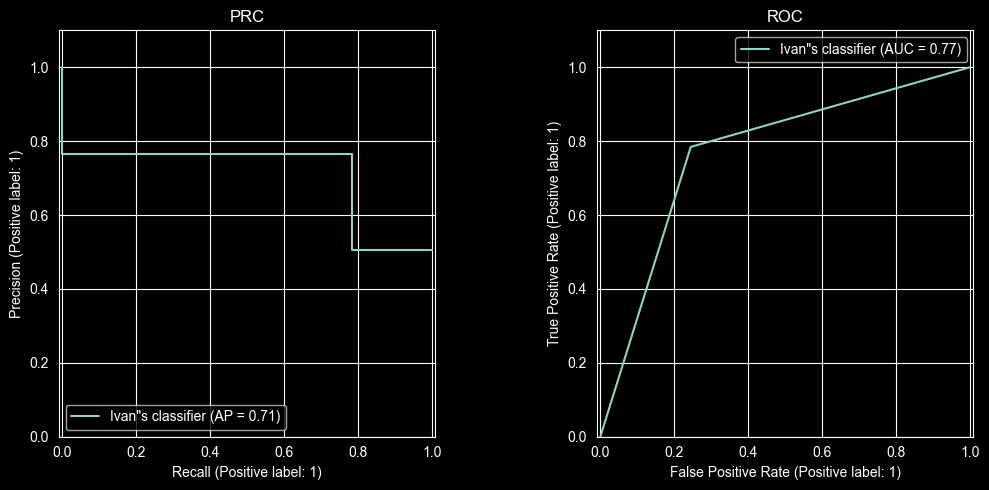

In [11]:
#  
def depict_pr_roc(y_test, svm_pred, classifier_name='Ivan"s classifier', ax=None):
  if ax is None:
    fig, ax = plt.subplots(1, 2, figsize=(11, 5))

  print(classifier_name, 'metrics')
  PrecisionRecallDisplay.from_predictions(y_test, svm_pred, ax=ax[0], name=classifier_name)
  precision, recall, _ = precision_recall_curve(y_test, svm_pred)
  print('AUC-PR: %.5f' % auc(recall, precision))
  ax[0].set_title("PRC")
  ax[0].set_ylim(0, 1.1)

  RocCurveDisplay.from_predictions(y_test, svm_pred, ax=ax[1], name=classifier_name)
  print('AUC-ROC: %.5f' % roc_auc_score(y_test, svm_pred))
  ax[1].set_title("ROC")
  ax[1].set_ylim(0, 1.1)

  plt.tight_layout()
  plt.legend()


depict_pr_roc(y_test, svm_pred, 'Ivan"s classifier')


Сравниваем AUC-ROC и AUC-PR для вашей модели с этими же метриками для случайного классификатора.

Random Classifier metrics
AUC-PR: 0.75283
AUC-ROC: 0.50000


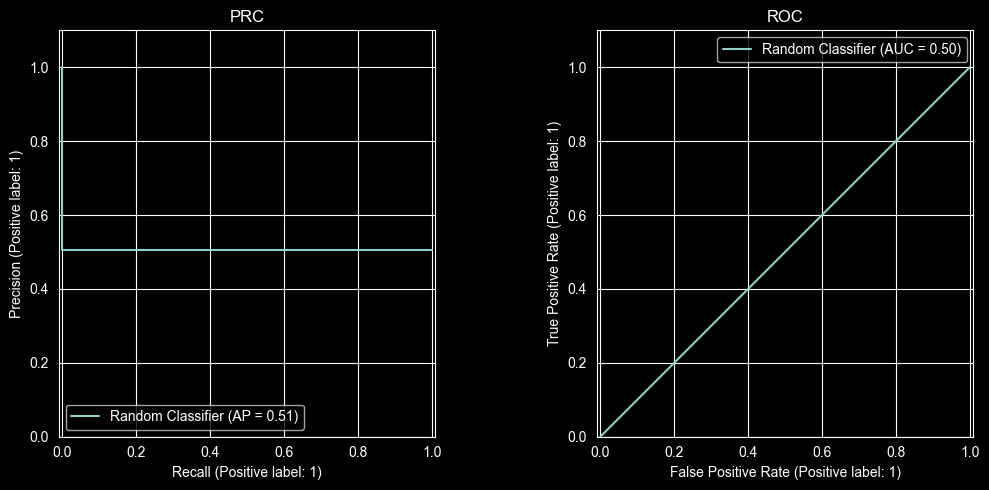

In [12]:
#  
# У моего классификатора метрики лучше, что было ожидаемо
def depict_pr_roc(y_test, svm_pred, classifier_name='Ivan"s classifier', ax=None):
  if ax is None:
    fig, ax = plt.subplots(1, 2, figsize=(11, 5))

  print(classifier_name, 'metrics')
  PrecisionRecallDisplay.from_predictions(y_test, svm_pred, ax=ax[0], name=classifier_name)
  precision, recall, _ = precision_recall_curve(y_test, svm_pred)
  print('AUC-PR: %.5f' % auc(recall, precision))
  ax[0].set_title("PRC")
  ax[0].set_ylim(0, 1.1)

  RocCurveDisplay.from_predictions(y_test, svm_pred, ax=ax[1], name=classifier_name)
  print('AUC-ROC: %.5f' % roc_auc_score(y_test, svm_pred))
  ax[1].set_title("ROC")
  ax[1].set_ylim(0, 1.1)

  plt.tight_layout()
  plt.legend()


depict_pr_roc(y_test, y_random, 'Random Classifier')


__Logistic Regression__


Аналогичное делаем для логистической регрессии с L2 регуляризатором:


*   подбераем гиперпараметр C, используя метрику AUC-PR
*   рисуем ROC, PR кривые для тестовой части
*   выводим метрики для тестовых данных и сравниваем их с результатами случайного классификатора



In [13]:
#  
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
param_grid2 = {
    'C': [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 10],
}
grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid2,
    cv=5,                # 5-fold CV
    scoring='average_precision',        # метрика
)

grid.fit(X_train, y_train)
best_model2 = grid.best_estimator_
print(best_model2.C)
lr = LogisticRegression(C=0.01)
lr.fit(X_train, y_train)

0.01


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mu

Ivan"s classifier metrics
AUC-PR: 0.83042
AUC-ROC: 0.77035


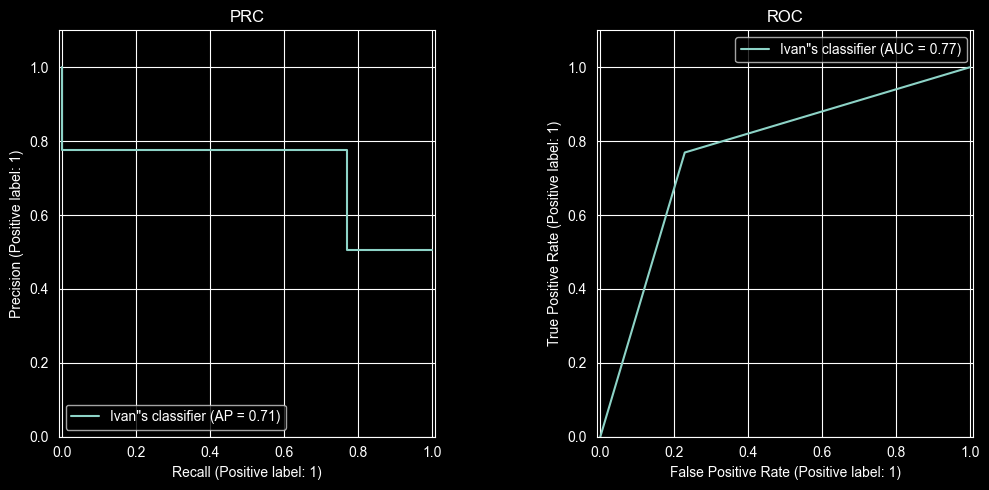

In [14]:
# метрики опять лучше чем у случайного классификатора
lr_pred = lr.predict(X_test)

def depict_pr_roc(y_test, y_pred, classifier_name='Ivan"s classifier', ax=None):
  if ax is None:
    fig, ax = plt.subplots(1, 2, figsize=(11, 5))

  print(classifier_name, 'metrics')
  PrecisionRecallDisplay.from_predictions(y_test, y_pred, ax=ax[0], name=classifier_name)
  precision, recall, _ = precision_recall_curve(y_test, y_pred)
  print('AUC-PR: %.5f' % auc(recall, precision))
  ax[0].set_title("PRC")
  ax[0].set_ylim(0, 1.1)

  RocCurveDisplay.from_predictions(y_test, y_pred, ax=ax[1], name=classifier_name)
  print('AUC-ROC: %.5f' % roc_auc_score(y_test, y_pred))
  ax[1].set_title("ROC")
  ax[1].set_ylim(0, 1.1)

  plt.tight_layout()
  plt.legend()


depict_pr_roc(y_test, lr_pred, 'Ivan"s classifier')

Нарисуем ROC, PR кривые для тестовой части для всех 3 классификаторов на одном графике

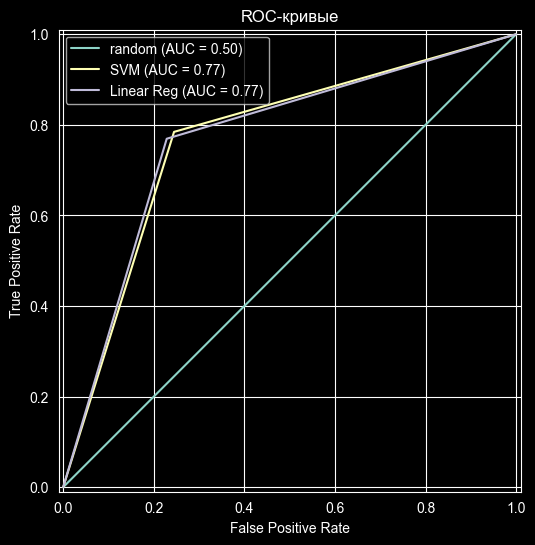

In [15]:
#  
fig, ax = plt.subplots(figsize=(8,6))  # создаём одну фигуру и ось

RocCurveDisplay.from_predictions(y_test, y_random, name="random", ax=ax)
RocCurveDisplay.from_predictions(y_test, svm_pred, name="SVM", ax=ax)
RocCurveDisplay.from_predictions(y_test, lr_pred, name="Linear Reg", ax=ax)

ax.set_title("ROC-кривые")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()




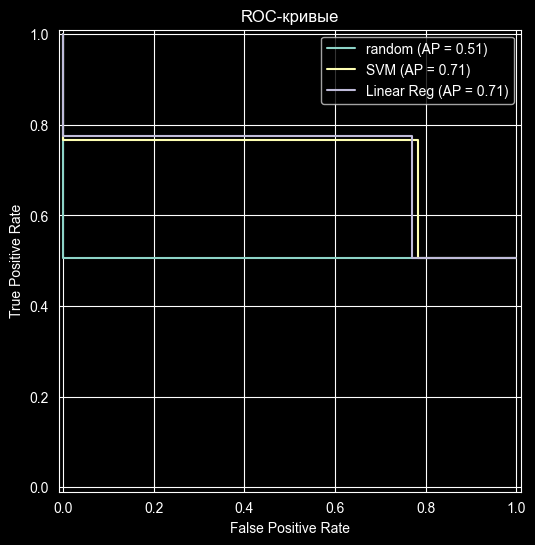

In [16]:
fig, ax = plt.subplots(figsize=(8,6))  # создаём одну фигуру и ось

PrecisionRecallDisplay.from_predictions(y_test, y_random, name="random", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, svm_pred, name="SVM", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, lr_pred, name="Linear Reg", ax=ax)

ax.set_title("ROC-кривые")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()

По метрикам особых различий нет


#### Визуализация в подходах SVM, Logistic Regression



В названии метода опорных векторов присутствуют некоторые "опорные векторы". По сути, это объекты из обучающей выборки, которые задали положение разделяющей гиперплоскости.

* Сгенерируем синтетические данные с помощью `make_classification` __с 2 признаками__, обучим на нём метод опорных векторов. В этот раз воспользуемся `SVC(kernel='linear')`, так как только в нём есть информация об опорных векторах, а в `LinearSVC` нет. Не забудем зафиксировать seed для воспроизводимости

* Визуализируем разделяющую прямую, все объекты и выделим опорные векторы (атрибут `support_vectors_`).

In [17]:
#  
np.random.seed(123)
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# фиксируем random_state для воспроизводимости результатов
X1, y1 = make_classification(
    n_samples=10000, n_features=2, n_informative=2, n_redundant=0, random_state=42)

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=42)
svm2 = SVC(kernel='linear')
svm2.fit(X_train1, y_train1)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


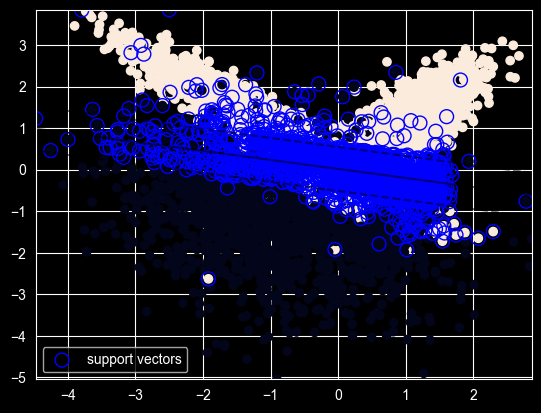

In [18]:
def plot_svm_2D(X, y, model, plot_support=True):

    #создали сетку
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 30)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    #Ответы модели для сетки для отрисовки разделяющей прямой
    Z = model.decision_function(xy).reshape([30,30])

    plt.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])


    #Отрисовали выборку
    plt.scatter(X[:,0], X[:,1], c=y)

    #Отрисовали опорные векторы
    if plot_support:
        plt.scatter(model.support_vectors_[:,0],
                    model.support_vectors_[:,1],
                   label='support vectors',
                   s=100,
                   linewidth=1,
                   edgecolor="blue",
                   facecolors='none')

    plt.legend()

model=SVC(kernel='linear').fit(X,y)

plot_svm_2D(X_train1, y_train1, svm2)

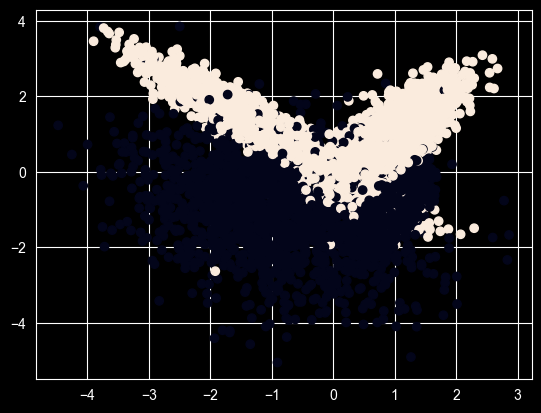

In [19]:
plt.scatter(X_train1[:, 0], X_train1[:, 1], c=y_train1);

Опорными стали объекты, которые находятся близко к границе

В отличие от метода опорных векторов, логистическая регрессия не пытается построить разделяющую гиперплоскость с максимальным отступом, а приближает в каждой точке пространства объектов вероятность положительных ответов $p(y=+1|x)$. Нарисуем это распределение на плоскости, не забудем отметить на ней все объекты.

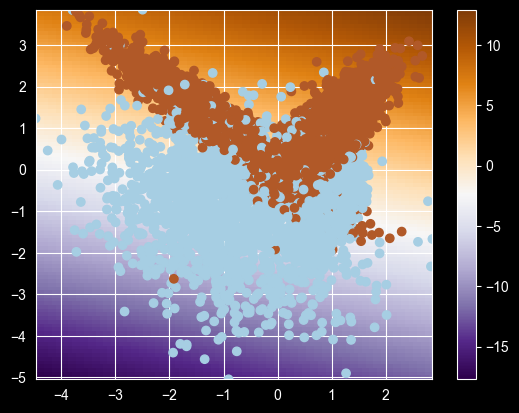

In [20]:
def plot_logreg_2D(X, y, model):

    # Задаем сетку
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Ответы модели для сетки для отрисовки распределения
    Z = model.decision_function(xy)
    Z = Z.reshape((xx.shape[0], -1)).T


    image = plt.imshow(Z, interpolation='nearest',
                       extent=(xx.min(), xx.max(), yy.min(), yy.max()),
                       aspect='auto', origin='lower', cmap=plt.cm.PuOr_r)

    # Отрисовываем выборку
    plt.scatter(X[:,0], X[:,1], c=y,
                cmap=plt.cm.Paired)

    plt.colorbar(image)

model = LogisticRegression().fit(X_train1, y_train1)
plot_logreg_2D(X_train1, y_train1, model)

**Вопрос:** Как на картинке визуализирована область, где модель не уверена ($p(y=+1|x) = 0.5$)? Как это обосновать теоритечески?



Область, где модель не уверена - это область примерно на границе. Чем ближе мы к гиперплоскости разделения классов в логистической регрессии, тем ближе результат к 0.5, так как аргумент сигмоиды примерно 0

# Работа с текстами

В этой части будем строить классификатор текстов!

Возьмем [данные из Kaggle соревнования](https://www.kaggle.com/competitions/nlp-getting-started/data).


Нужно скачать файл train.csv. На обучающую и тестовую выборки его поделим кодом ниже!

Мы будем работать с датасетом постов из твиттера. Нам предстоит решать задачу бинарной классификации - определять содержатся ли в твитте информация о настоящей катастрофе/инциденте или нет.

In [21]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [22]:
# Также файл можно загрузить так:

!wget https://raw.githubusercontent.com/SergeyKorpachev/math-faculty-ml/refs/heads/main/2026/homework/homework02/train.csv .

"wget" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [23]:
data = pd.read_csv('train.csv')
data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [24]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.3, random_state=42)

In [25]:
data['target']

0       1
1       1
2       1
3       1
4       1
       ..
7608    1
7609    1
7610    1
7611    1
7612    1
Name: target, Length: 7613, dtype: int64

#### Пропуски

Выведем на экран информацию о пропусках в данных. Если пропуски присутствуют заполним их пустой строкой.

In [26]:

data.isna().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

In [27]:
data['keyword'] = data['keyword'].fillna('')
data['location'] = data['location'].fillna('')
data.isna().sum()

id          0
keyword     0
location    0
text        0
target      0
dtype: int64

#### Разведочный анализ данных

Давайте немного посмотрим на наши данные. Визуализируем или выведем информацию о следующем:

1. Какое распределение классов в обучающей выборке?


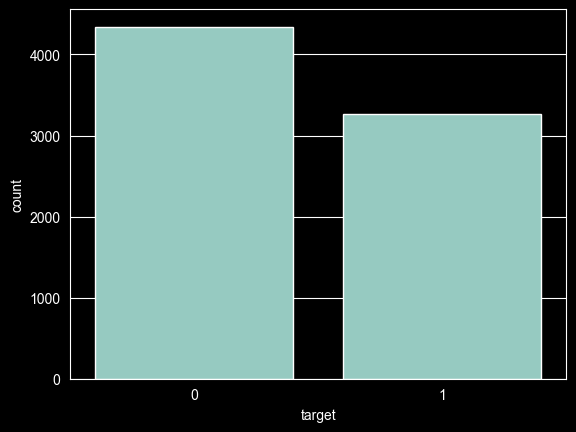

In [28]:

sns.countplot(x='target', data=data)
plt.show()

Класс 0 преобладает

2. Посмотрим на колонку "keyword" - возьмём 10 наиболее встречающихся значений, построим ступенчатую диаграмму распределения классов в зависимости от значения keyword, сделаем выводы.

In [29]:

data['keyword'].value_counts().head(10)

keyword
               61
fatalities     45
armageddon     42
deluge         42
body%20bags    41
damage         41
harm           41
sinking        41
collided       40
evacuate       40
Name: count, dtype: int64

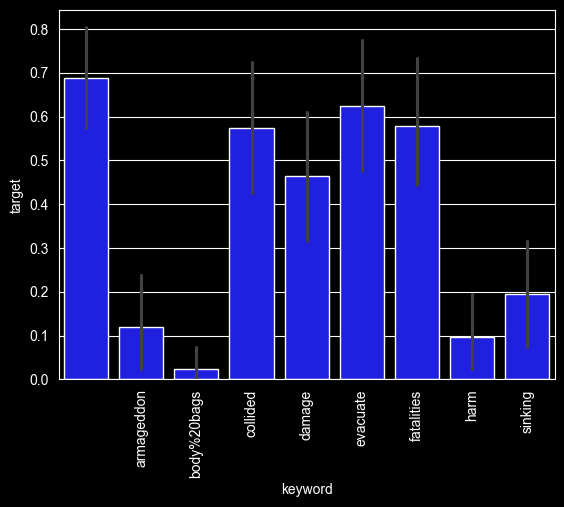

In [30]:

popular_keywords = ['', 'fatalities', 'armageddon', 'deluge ', 'body%20bags', 'damage', 'harm', 'sinking', 'collided',
                    'evacuate']

#  
popular_data = data[data['keyword'].isin(popular_keywords)]
sns.barplot(
    x='keyword',
    y='target',
    data=popular_data,
    color='blue',
estimator='mean')
plt.xticks(rotation=90)
plt.show()

Тексты с пустыми строками были в основном с таргетом 1. У основной же массы других ключевых слов средний таргет около 0.5-0.6

#### Подготовка

В этом задании предлагается объединить все три текстовых столбца в один (просто сконкатенировать cтроки) и убрать столбец с индексом.

In [31]:
train.loc[[6590, 7122, 2769]]

,id,keyword,location,text,target
6590,9436,survivors,"Marietta, GA",Stemming from my #Cubs talk- the team rosters ...,1
7122,10203,violent%20storm,NaN,If you were the NWS wth a rotating storm w/ a ...,1
2769,3980,devastation,Atlanta g.a.,http://t.co/Gxgm1T3W0J From Devastation to Ela...,0


In [32]:
#  
data = data.drop('id', axis=1)
data['text'] = data['keyword'] + data['location'] + data['text']


In [33]:
data.head(150)

,keyword,location,text,target
0,,,Our Deeds are the Reason of this #earthquake M...,1
1,,,Forest fire near La Ronge Sask. Canada,1
2,,,All residents asked to 'shelter in place' are ...,1
3,,,"13,000 people receive #wildfires evacuation or...",1
4,,,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...
145,airplane%20accident,bangalore,airplane%20accidentbangalore#Horrible #Acciden...,1
146,airplane%20accident,Financial News and Views,airplane%20accidentFinancial News and ViewsExp...,1
147,airplane%20accident,,airplane%20accidentExperts in France begin exa...,1
148,airplane%20accident,Indonesia,airplane%20accidentIndonesia#KCA #VoteJKT48ID ...,1


In [34]:
train_new, test_new = train_test_split(data, test_size=0.3, random_state=42)
train_new.loc[[6590, 7122, 2769]]

,keyword,location,text,target
6590,survivors,"Marietta, GA","survivorsMarietta, GAStemming from my #Cubs ta...",1
7122,violent%20storm,,violent%20stormIf you were the NWS wth a rotat...,1
2769,devastation,Atlanta g.a.,devastationAtlanta g.a.http://t.co/Gxgm1T3W0J ...,0


Далее мы будем пока работать только с train частью. Предобработаем данные (train часть) с помощью CountVectorizer.

In [35]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(encoding='utf8')
_ = vectorizer.fit(train_new['text'])
len(vectorizer.vocabulary_)
# матрица будет равна len(vectorizer.vocabulary_) * train_new.shape[0] = 22738 * 5329
len(vectorizer.vocabulary_)

22738

In [36]:
vectorizer.transform(train_new['text'])
vectorizer.vocabulary_

{'bridge': 4091,
 '20collapseashes': 504,
 '2015': 297,
 'australia': 2943,
 'ûªs': 22707,
 'collapse': 5237,
 'at': 2820,
 'trent': 20306,
 'among': 2350,
 'worst': 21971,
 'in': 11061,
 'history': 10473,
 'england': 7870,
 'bundled': 4222,
 'out': 15090,
 'for': 9084,
 '60': 1403,
 'http': 10695,
 'co': 5182,
 't5trhjuau0': 19380,
 'hailcarol': 9993,
 'stream': 18995,
 'illinoisgreat': 10989,
 'michigan': 13511,
 'technique': 19526,
 'camp': 4474,
 'b1g': 3074,
 'thanks': 19699,
 'to': 20008,
 'bmurph1019': 3851,
 'hail_youtsey': 9986,
 'termn8r13': 19586,
 'goblue': 9674,
 'wrestleon': 22109,
 'oaskgki6qj': 14664,
 'policehouston': 15805,
 'cnn': 5175,
 'tennessee': 19568,
 'movie': 13876,
 'theater': 19710,
 'shooting': 18069,
 'suspect': 19282,
 'killed': 12076,
 'by': 4323,
 'police': 15800,
 'di8elzswnr': 6877,
 'riotingstill': 17117,
 'rioting': 17099,
 'couple': 5651,
 'of': 14773,
 'hours': 10651,
 'left': 12510,
 'until': 20834,
 'have': 10159,
 'be': 3318,
 'up': 20845,
 'c

#### Работа со словарем


В предыдущем пункте у вас получилась достаточно большая матрица.
Если мы взглянем на текст, то увидим, что там есть множество специальных символов, ссылок и прочего мусора.

Давайте также посмотрим на словарь, который получился в результате построения CountVectorizer, его можно найти в поле vocabulary_ инстанса этого класса. Давайте напишем функцию, которая печатает ответы на следующие вопросы:

1. Найдём в этом словаре все слова, которые содержат цифры.

2. Найдём все слова, которые содержат символы пунктуации.

3. Сколько хэштегов (токен начинается на #) и упоминаний (токен начинается на @) осталось в словаре?

In [37]:
def contains_digit(s: str) -> bool:
    digits = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
    return any(char in digits for char in s)


def contains_punctuation(s: str) -> bool:
    return any(char in punctuation for char in s)
    # Проверка, содержит ли слово пунктуацию

def is_hashtag(s: str) -> bool:
    return len(s) > 0 and s[0] == '#'

    # Проверка, является ли слово хэштегом

def is_mention(s: str) -> bool:
    # Проверка, является ли слово упоминанием
    return len(s) > 0 and s[0] == '@'

def investigate_vocabulary(vocabulary):
    digit_count = 0
    punctuation_count = 0
    hashtag_count = 0
    mention_count = 0
    for word in vocabulary:
        digit_count += contains_digit(word)
        punctuation_count += contains_punctuation(word)
        hashtag_count += is_hashtag(word)
        mention_count += is_mention(word)
    print('With digit:      ', digit_count
          )
    print('With punctuation:', punctuation_count
          )
    print('Hashtags:        ', hashtag_count
          )
    print('Mentions:        ', mention_count
          )

In [38]:
dummy_vocab = {'th1nk' : 0,
               'think333' : 1,
               'think.' : 2,
               'th!nk' : 3,
               'th...nk' : 4,
               '#think' : 5,
               '@think' : 6,
               '@thinking':7,
               '@nothink' : 8,
               'think' : 9}

investigate_vocabulary(dummy_vocab)

With digit:       2
With punctuation: 7
Hashtags:         1
Mentions:         3


In [39]:
investigate_vocabulary(
    vectorizer.vocabulary_
)

With digit:       4590
With punctuation: 317
Hashtags:         0
Mentions:         0


#### Токенизация

По умолчанию CountVectorizer определяет токен (слово) как последовательность 2 и более цифр или букв. Пунктуационные символы воспринимаются как разделитель токенов. Такой подход может быть не очень полезен при анализе твитов.

Существуют токенайзеры - модели, которые разбивают тексты на токены (слова), они разные в зависимости от задачи (какие токены могут быть полезны в данной задаче?). Например, в nltk есть токенизатор для твитов - TweetTokenizer.

Попробуем применить CountVectorizer с этим токенизатором. 

In [40]:
from nltk.tokenize import TweetTokenizer
from collections import Counter

tt = TweetTokenizer()
train_new['tt_tokens'] = train_new['text'].apply(tt.tokenize)
vocab = set(train_new['tt_tokens'].sum())
vocab
# Чтобы узнать, какие параметры есть у этого токенайзера - используйте help(TweetTokenizer)
# Для того, чтобы передать токенайзер в CountVectorizer используйте параметр tokenizer

#  

{'Mounts',
 'flood--rainstorm',
 '44.414510',
 'http://t.co/ko0oz3RYFg',
 '@SagaciousSaber',
 'saat',
 'Cricket',
 'GASomehow',
 'proven',
 '#yycweather',
 'debrisWorld',
 'describes',
 'screamsFlorida',
 '@davidlabrava',
 'pikin',
 'sirensReasons',
 'ML',
 '876',
 '#robot',
 'Sarah',
 'Foundation',
 'LMFAO',
 'http://t.co/Eq4rXC9bb3',
 'disasterTV',
 'Cecil',
 '2008',
 'Hate-Violence',
 'http://t.co/qWgIwC9w7Z',
 'snowflake',
 '3.1',
 'FRUIT',
 'http://t.co/Pw78nblJKy',
 '#Jackson',
 '@angel_star39',
 'rainstormGloucester',
 'illogical',
 'rescuing',
 'meeting',
 'Fazbears',
 'somewhereFire',
 'earthquakeSeattle',
 'londonThe',
 'fearSt',
 'armageddonWrigley',
 'incremental',
 'spirit',
 'public',
 'drowningLouis',
 'screamsI',
 'sunkIn',
 'big-tent',
 'sinkholeAbove',
 '#drained',
 'upheavalWisconsin',
 '20bagsIn',
 'seek',
 'apocalypsesindriaohH',
 'hijackeating',
 'Left',
 'Veneto',
 'StatesAre',
 'haram',
 'bear',
 'McGwire',
 '@SkyNews',
 'FAKE',
 'http://t.co/YO3T8qho9h',
 'advi

In [41]:
investigate_vocabulary(
    vocab
)

With digit:       4625
With punctuation: 7731
Hashtags:         1570
Mentions:         1686


**Сравнение:** Ожидаемым образом у нас и упоминания и хэштеги появились, так как мы теперь не считаем их знаками пунктуации как раньше

#### Кастомный токенайзер


В scikit-learn мы можем оценивать процесс подсчета матрицы через CountVectorizer. У CountVectorizer, как и у других наследников \_VectorizerMixin, есть аргумент tokenizer и preprocessor. preprocessor применится в самом начале к каждой строке вашего датасета, tokenizer же должен принять строку и вернуть токены.
Давайте напишем кастомный токенайзер, которые сделает все, что нам нужно:

0. Приведет все буквы к нижнему регистру
1. Разобьет текст на токены с помощью TweetTokenizer из пакета nltk
2. Удалит все токены содержащие не латинские буквы, кроме смайликов (будем считать ими токены содержащие только пунктуацию и, как минимум, одну скобочку) и хэштегов, которые после начальной # содержат только латинские буквы.
3. Удалит все токены, которые перечислены в nltk.corpus.stopwords.words('english')
4. Проведет стемминг с помощью SnowballStemmer


In [42]:
import nltk
nltk.download('stopwords')
nltk.corpus.stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [43]:
from string import punctuation
from nltk.stem import SnowballStemmer
def contains_only_latin_letters(s: str) -> bool:
    return s.isascii() and s.isalpha()
    # Проверка, содержит ли слово только латинские буквы

def is_emoji(s: str) -> bool:
    # Проверка, является ли слово смайликом
    return all(ch in punctuation for ch in s) and ('(' in s or ')' in s)


def is_hashtag(s: str) -> bool:
    return len(s) > 0 and s[0] == '#'

def custom_tokenizer(s: str) -> List[str]:
    # Кастомный токенайзер
    s = s.lower()
    tt = TweetTokenizer()
    tt_s = tt.tokenize(s)

    #  
    for word in tt_s:
        if not is_emoji(word) and not is_hashtag(word) and not contains_only_latin_letters(word):
            tt_s.remove(word)
        elif word in nltk.corpus.stopwords.words('english'):
            tt_s.remove(word)
    stemmer = SnowballStemmer("english")
    stemmed_words = [stemmer.stem(w) for w in tt_s]
    return stemmed_words

In [44]:
custom_tokenizer('She LOVES painting :-) #art аыаыа')

['love', 'paint', ':-)', '#art']

Продемонстрируем работу нашей функции на первых десяти текстах в обучающей выборке.

In [45]:
#  
df_subset = train_new.head(10)
result = df_subset['text'].apply(custom_tokenizer)
print(result)

1186    [bridg, 20collapseash, australia, ûªs, collaps...
4071    [hailcarol, stream, illinoisgreat, michigan, t...
5461    [policehouston, cnn, tennesse, movi, theater, ...
5787    [riotingstil, riot, a, coupl, hour, left, i, t...
7445    [woundslak, highlandscrack, the, path, i, wipe...
151     [airplan, 20accidentsomewher, thereexpert, fra...
915     [bloodyisol, citi, world, came, kill, indian, ...
1305          [burn, except, idk, it, realli, burn, ?, ?]
2570    [destroyh, him, she, her, (, ask, ), destroy, ...
7399    [woundedmaracay, nirgua, venezuelapolic, offic...
Name: text, dtype: object


#### Обучаем модель

1. Применним CountVectorizer с реализованным выше токенизатором к обучающим и тестовым выборкам.

2. Обучим LogisticRegression на полученных признаках.

3. Посчитаем метрику f1-score на тестовых данных.

In [46]:
#  
vectorizer = CountVectorizer(encoding='utf8', tokenizer=custom_tokenizer)
X_train = vectorizer.fit_transform(train_new['text'])
X_test =  vectorizer.transform(test_new['text'])
y_train = train_new['target']
y_test = test_new['target']


C:\Users\user\PycharmProjects\ML дз 2\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [47]:
from sklearn.metrics import f1_score

logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)
y_pred = logistic_model.predict(X_test)
f1_score(y_test, y_pred) # 0.76

0.7560706401766004

#### Другой векторайзер и df

Повторим, но с tf-idf векторайзером. Как изменилось качество?

In [48]:
#  
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer2 = TfidfVectorizer(encoding='utf8', tokenizer=custom_tokenizer)
X_train2 = vectorizer2.fit_transform(train_new['text'])
X_test2 =  vectorizer2.transform(test_new['text'])
y_train2 = train_new['target']
y_test2 = test_new['target']


C:\Users\user\PycharmProjects\ML дз 2\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [49]:
logistic_model2 = LogisticRegression()
logistic_model2.fit(X_train2, y_train2)
y_pred2 = logistic_model2.predict(X_test2)
f1_score(y_test2, y_pred2) # 0.74

0.742792538157151

**Качество просело**

В векторайзерах есть параметры min_df и max_df - которые отвечают за ограничния минимальной и максимальной частоте встречаемости токена. Например, если min_df = 3, то мы не учитываем токены, которые встретились менее 3 раз в наших текстах.

Мы можем еще сильнее уменьшить размер нашей матрицы, если отбросим значения df близкие к единице. Скорее всего такие слова не несут много информации о категории, так как встречаются достаточно часто. Ограничьте максимальный df в параметрах TfIdfVectorizer, поставьте верхнюю границу равную 0.9.

In [50]:
#  
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer3 = TfidfVectorizer(encoding='utf8', max_df = 0.9, tokenizer=custom_tokenizer)
X_train3 = vectorizer3.fit_transform(train_new['text'])
X_test3 =  vectorizer3.transform(test_new['text'])
print(len(vectorizer3.vocabulary_)) # 17275, было ~22000, т.е размер уменьшился

y_train3 = train_new['target']
y_test3 = test_new['target']

C:\Users\user\PycharmProjects\ML дз 2\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


17275


In [51]:
print(len(vectorizer3.vocabulary_))

17275


In [52]:
logistic_model3 = LogisticRegression()
logistic_model3.fit(X_train3, y_train)
y_pred3 = logistic_model3.predict(X_test3)
f1_score(y_test3, y_pred3) # 0.74

0.742792538157151

**Размер уменьшился, качество особо не поменялось**


Также мы можем уменьшить размер матрицы, удаляя слова со слишком маленьким df. Удастся ли добиться улучшения качества?

In [53]:
#  
vectorizer4 = TfidfVectorizer(encoding='utf8', min_df = 2, max_df = 0.9, tokenizer=custom_tokenizer)
X_train4 = vectorizer4.fit_transform(train_new['text'])
X_test4 =  vectorizer4.transform(test_new['text'])
print(len(vectorizer4.vocabulary_)) # 17275, было ~22000, т.е размер уменьшился

y_train4 = train_new['target']
y_test4 = test_new['target']
logistic_model4 = LogisticRegression()
logistic_model4.fit(X_train4, y_train4)
y_pred4 = logistic_model4.predict(X_test4)
f1_score(y_test4, y_pred4)

C:\Users\user\PycharmProjects\ML дз 2\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


4811


0.7399887196841511

**Качество при добавлении параметра min_df стало чуть меньше, около 0.74. Не улучшилось**

Я также решил сделать grid search, чтобы подобрать оптимальные параметры. Приходилось дальше ждать, но поднять f1 выше чем ~0.76 у меня не получилось

In [110]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV




pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('model', LogisticRegression()),

])

param_grid = {
    'vectorizer__min_df': [1, 2, 3, 4, 5, 10, 100],
    'vectorizer__max_df': [0.1, 0.2, 0.4, 0.5, 0.7, 0.8, 0.85, 0.9, 1],
    'vectorizer__tokenizer': [None],
    'model__C': [0.01, 0.1, 0.4, 0.5, 1, 10, 100]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs = -1
)


grid.fit(train_new['text'], train_new['target'])

print(grid.best_params_)


C:\Users\user\PycharmProjects\ML дз 2\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
210 fits failed out of a total of 2205.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
210 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\user\PycharmProjects\ML дз 2\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\user\PycharmProjects\ML дз 2\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\user\PycharmProjects\ML дз 2\.venv\Lib\si

{'model__C': 0.4, 'vectorizer__max_df': 0.2, 'vectorizer__min_df': 1, 'vectorizer__tokenizer': None}


In [115]:
# search.best_params_
best_model = grid.best_estimator_
y_preds = best_model.predict(test_new['text'])
f1_score(test_new['target'], y_preds)



0.7506971556051311

In [139]:
vectorizer5 = TfidfVectorizer(encoding='utf8', norm='l2', min_df = 2, max_df = 0.9, max_features=10000)
vectorizer5.fit(train_new['text'])
X_test5 =  vectorizer5.transform(test_new['text'])
X_train5 =  vectorizer5.transform(train_new['text'])
logreg5 = LogisticRegression()
logreg5.fit(X_train5, train_new['target'])
preds5 = logreg5.predict(X_test5)
f1_score(test_new['target'], preds5)

0.7438955139125497

In [ ]:
grid.score